# All-Weather ⛅
### Does the famous risk-parity portfolio really beat everything?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![All-weather portfolio that beats everything?: Overstated](https://img.shields.io/badge/All--weather_portfolio_that_beats_everything%3F-Overstated-8b949e?style=flat-square)

Ray Dalio's All-Weather idea: don't weight by dollars, weight by *risk* — so stocks, bonds, gold and commodities each contribute equally and no single market can sink you. The diversification is real: it earned the best risk-adjusted return and a drawdown a third of the stock market's. But unlevered it returned only *half* of plain stocks.

> 📓 **Plain-language layer.** The four allocations, the Sharpe/drawdown win and the leverage caveat are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every number is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (all_weather/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from all_weather import data, strategy as st
ret = data.fetch_panel()                       # cache-first (shared cross-asset pull)
tbl = st.compare(ret)


## The answer first 🎯

| The question | The data (SPY/IEF/GLD/DBC, 2006–2026) |
|---|---|
| "Does risk parity diversify?" | Yes: **Sharpe 0.92**, drawdown **−17%** — best of the four. |
| "Does it beat stocks?" | No: **+6.7%/yr vs SPY +12.6%** — about half the return. |
| "So is it magic?" | No — a smoother ride, not a bigger one (without leverage). |

## 1 · The claim

Weight each asset inversely to its volatility, rebalance, and you get a portfolio balanced by *risk* — calm Treasuries and gold offsetting jumpy stocks. The folk version: *an all-weather portfolio that wins in every regime and beats a stock/bond mix.*

## 2 · So what?

If it truly dominates, it's the obvious core allocation — buy four ETFs and go to sleep. The honest question is *on what axis* it wins: risk-adjusted return, or absolute return? They're very different promises.

## 3 · How would we even know?

Build risk parity unlevered on SPY/IEF/GLD/DBC, rebalance monthly, and line it up against equal-weight, 60/40 and plain SPY on return, volatility, Sharpe and drawdown over 20 years.

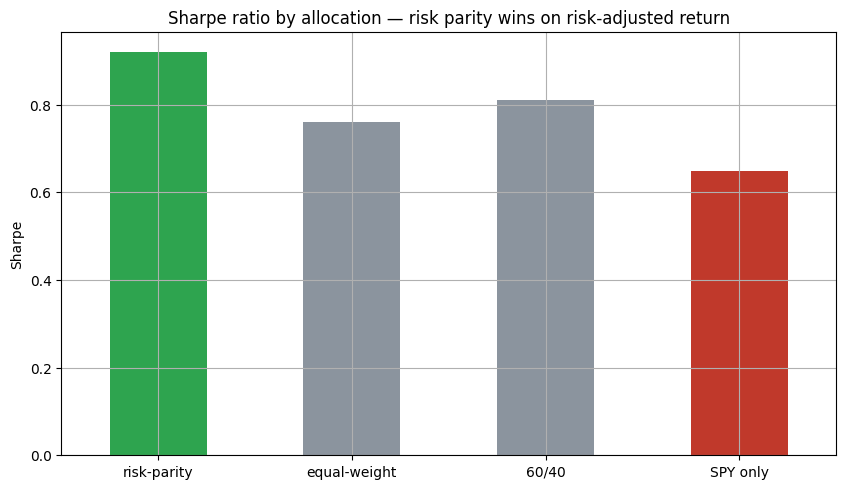

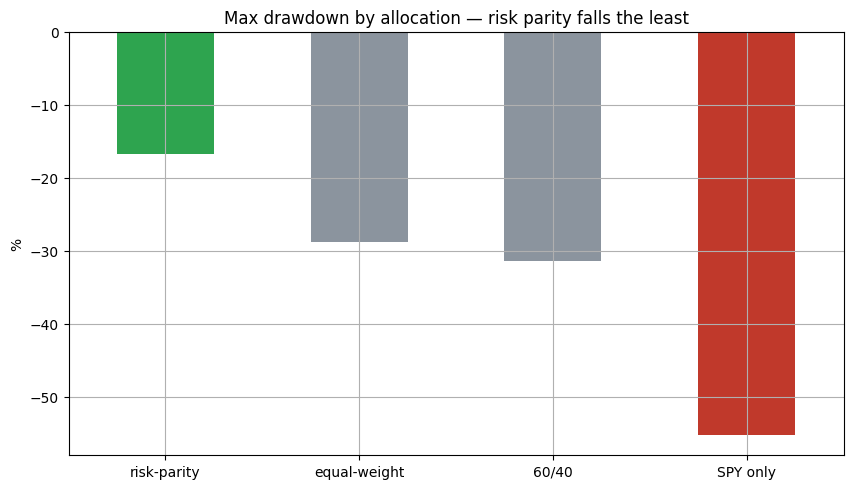

In [2]:
ax=tbl['sharpe'].plot.bar(rot=0,color=['#2ea44f','#8b949e','#8b949e','#c0392b'],
    title='Sharpe ratio by allocation — risk parity wins on risk-adjusted return')
ax.set_ylabel('Sharpe'); plt.show()
(tbl['max_drawdown']*100).plot.bar(rot=0,color=['#2ea44f','#8b949e','#8b949e','#c0392b'],
    title='Max drawdown by allocation — risk parity falls the least'); plt.ylabel('%'); plt.show()

## 4 · The teardown — better Sharpe, half the return

Risk parity tops the Sharpe and drawdown tables and sits at the *bottom* of the return table. That's the whole trade-off.

In [3]:
show=tbl.copy()
for c in ['ann','vol','max_drawdown']: show[c]=(show[c]*100).round(1)
show['sharpe']=show['sharpe'].round(2)
display(show[['ann','vol','sharpe','max_drawdown']])

,ann,vol,sharpe,max_drawdown
risk-parity,6.7,7.3,0.92,-16.7
equal-weight,7.7,10.2,0.76,-28.7
60/40,9.1,11.2,0.81,-31.4
SPY only,12.6,19.3,0.65,-55.2


**Read it plainly.** Capping volatility at ~7% caps return at ~7%. To turn that smooth 0.92 Sharpe into equity-like *returns* you have to lever it ~2.7× — which brings back the drawdown risk you just removed, costs financing, and leans on bonds staying calm and positive (which 2022 blew up).

## 5 · The verdict

**Signal: Real** — genuinely better Sharpe and drawdown. **Tradability: Investable** — four cheap ETFs. **Beats everything?: Overstated** — unlevered it returns half of stocks; the magic needs leverage and a bond bull.

## 6 · Could you actually trade it?

Yes — as a *calmer core*, not a return machine. If you want a smoother ride and a −17% worst case instead of −55%, risk parity delivers. If you want to *beat* equities you must lever it, and then you own the leverage and bond-regime risk that the marketing leaves out.

## 7 · Going further 🚪

The allocation cousin of the diversifier studies [69 Safe-Haven](../../69-safe-haven/) (gold) and [70 Digital-Gold](../../70-digital-gold/) (bitcoin). Forks: levered risk parity (to a vol target), equal risk *contribution* (vs naïve inverse-vol), regime-conditioning, the post-2022 stock-bond correlation break.